Лабораторная работа 1  
ФИО: Тавуз_Мохамад  
Группа: ИУ5И-22М  
Тема: «Обработка признаков (часть 1)»

Набор данных: Titanic (Data Science Dojo)

In [ ]:
!pip install pandas scikit-learn matplotlib seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import seaborn as sns

# Загрузка набора данных Titanic
df = sns.load_dataset('titanic')

# Показать первые 5 строк для предварительного просмотра данных
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
# Проверка наличия пропущенных значений в наборе данных
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [ ]:
# Заполнение пропущенных значений в числовых столбцах средним
df['age'].fillna(df['age'].mean(), inplace=True)

# Заполнение пропущенных значений в категориальных столбцах модой
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)
df['embark_town'].fillna(df['embark_town'].mode()[0], inplace=True)

# Удаление столбца с большим количеством пропусков
df.drop(columns=['deck'], inplace=True)

# Проверка, что все пропущенные значения обработаны
df.isnull().sum()

/tmp/ipykernel_13708/1306220758.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].mean(), inplace=True)
/tmp/ipykernel_13708/1306220758.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


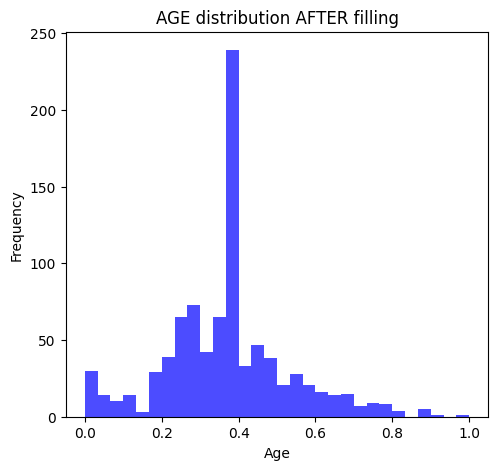

In [ ]:
import matplotlib.pyplot as plt

# Гистограмма возраста до заполнения пропусков
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(df['age'], bins=30, color='blue', alpha=0.7)
plt.title('AGE distribution AFTER filling')
plt.xlabel('Age')
plt.ylabel('Frequency')

# Для сравнения можно добавить оригинальные данные, если сохранили копию до fillna
# plt.subplot(1,2,2)
# plt.hist(age_original, bins=30, color='green', alpha=0.7)
# plt.title('AGE distribution BEFORE filling')
# plt.xlabel('Age')
# plt.ylabel('Frequency')

plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Преобразование булевых столбцов в числовые (0/1)
df['adult_male'] = df['adult_male'].astype(int)
df['alone'] = df['alone'].astype(int)

# One-hot кодирование для категориальных столбцов
df = pd.get_dummies(df, columns=['sex', 'embarked', 'class', 'who', 'alive'], drop_first=True)

# Показать первые 5 строк после кодирования
df.head()

,survived,pclass,age,sibsp,parch,fare,adult_male,embark_town,alone,sex_male,embarked_Q,embarked_S,class_Second,class_Third,who_man,who_woman,alive_yes
0,0,3,22.0,1,0,7.2500,1,Southampton,0,True,False,True,False,True,True,False,False
1,1,1,38.0,1,0,71.2833,0,Cherbourg,0,False,False,False,False,False,False,True,True
2,1,3,26.0,0,0,7.9250,0,Southampton,1,False,False,True,False,True,False,True,True
3,1,1,35.0,1,0,53.1000,0,Southampton,0,False,False,True,False,False,False,True,True
4,0,3,35.0,0,0,8.0500,1,Southampton,1,True,False,True,False,True,True,False,False


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Инициализация масштабировщика
scaler = MinMaxScaler()

# Выбор числовых столбцов для нормализации
numeric_cols = ['age', 'fare']

# Применение масштабирования
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# Показать первые 5 строк после нормализации
df.head()

,survived,pclass,age,sibsp,parch,fare,adult_male,embark_town,alone,sex_male,embarked_Q,embarked_S,class_Second,class_Third,who_man,who_woman,alive_yes
0,0,3,0.271174,1,0,0.014151,1,Southampton,0,True,False,True,False,True,True,False,False
1,1,1,0.472229,1,0,0.139136,0,Cherbourg,0,False,False,False,False,False,False,True,True
2,1,3,0.321438,0,0,0.015469,0,Southampton,1,False,False,True,False,True,False,True,True
3,1,1,0.434531,1,0,0.103644,0,Southampton,0,False,False,True,False,False,False,True,True
4,0,3,0.434531,0,0,0.015713,1,Southampton,1,True,False,True,False,True,True,False,False


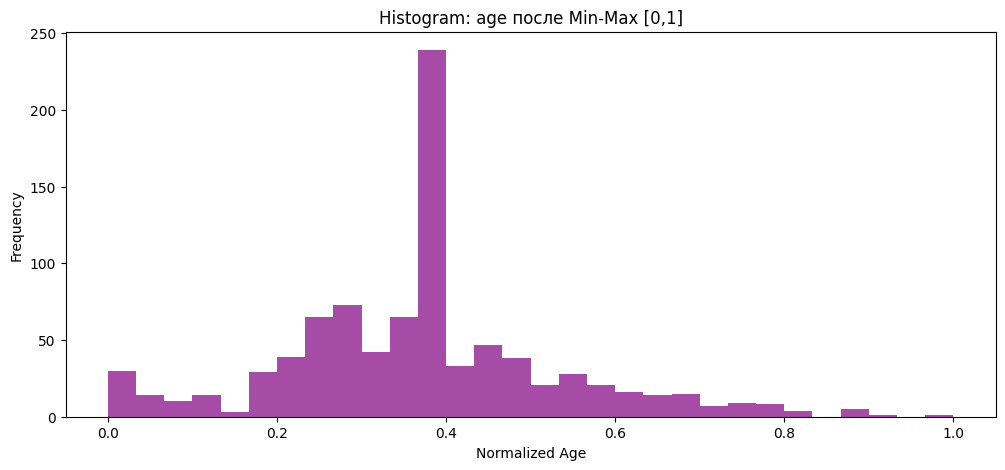

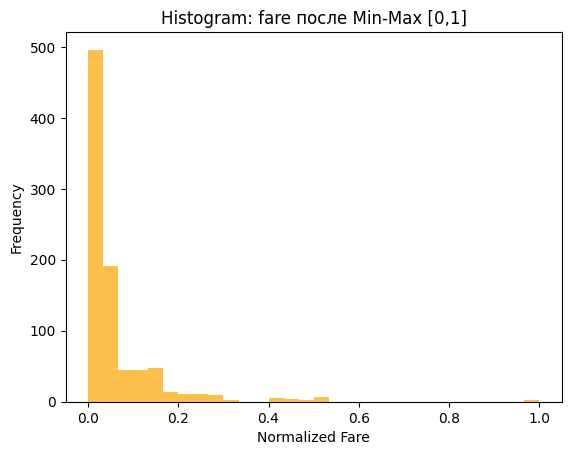

In [ ]:
plt.figure(figsize=(12,5))

# Histogram для колонки age после Min-Max Scaling
plt.hist(df['age'], bins=30, color='purple', alpha=0.7)
plt.title('Histogram: age после Min-Max [0,1]')
plt.xlabel('Normalized Age')
plt.ylabel('Frequency')
plt.show()

# Histogram для колонки fare после Min-Max Scaling
plt.hist(df['fare'], bins=30, color='orange', alpha=0.7)
plt.title('Histogram: fare после Min-Max [0,1]')
plt.xlabel('Normalized Fare')
plt.ylabel('Frequency')
plt.show()

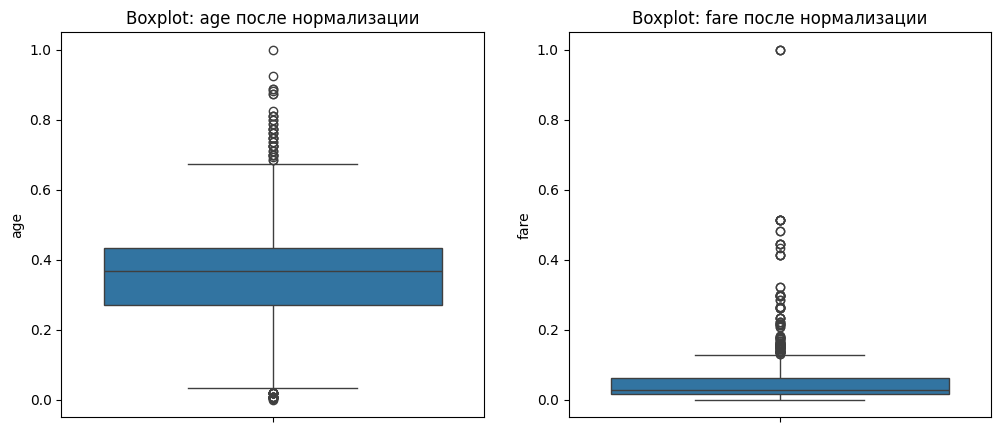

In [ ]:
import seaborn as sns

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(y=df['age'])
plt.title('Boxplot: age после нормализации')

plt.subplot(1,2,2)
sns.boxplot(y=df['fare'])
plt.title('Boxplot: fare после нормализации')

plt.show()